# Phase 0
- Synthetic data generation
- Kinematic model (baseline) building
- Sanity validation on Kinematic model
- KITTI setup (columns + train/test split)
- KITTI noise injection
- PINN build
- PINN train
- testing PINN + Kinematic model on KITTI (test set)

## Section 1: Unicycle integrator
takes IMU sequences (ax, wz) and integrates them through the unicycle model to produce a trajectory (x, y, v, yaw).

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path

# Reproducibility
np.random.seed(0)

print("Imports OK")

Imports OK


We use forward Euler to discretize this — meaning at each timestep, we use the current state to compute derivatives, then add derivative · dt to get the next state


In [2]:
def dead_reckon_unicycle(ax, wz, dt, x0=0.0, y0=0.0, v0=0.0, yaw0=0.0):
    """
    Forward-Euler integration of the unicycle model.
    
    Inputs:
        ax, wz : 1D numpy arrays of length N. IMU readings.
        dt     : either a scalar (uniform timestep) or a 1D array of length N
                 with per-step dt. KITTI has slightly variable dt, so we
                 support both.
        x0, y0, v0, yaw0 : initial state.
    
    Returns:
        x, y, v, yaw : 1D numpy arrays of length N. The trajectory.
    """
    N = len(ax)
    x = np.zeros(N); y = np.zeros(N); v = np.zeros(N); yaw = np.zeros(N)
    x[0], y[0], v[0], yaw[0] = x0, y0, v0, yaw0

    # Allow dt to be either scalar or per-step array
    if np.isscalar(dt):
        dts = np.full(N, dt)
    else:
        dts = dt

    for k in range(N - 1):
        x[k+1]   = x[k]   + v[k] * np.cos(yaw[k]) * dts[k]
        y[k+1]   = y[k]   + v[k] * np.sin(yaw[k]) * dts[k]
        v[k+1]   = v[k]   + ax[k] * dts[k]
        yaw[k+1] = yaw[k] + wz[k] * dts[k]
    return x, y, v, yaw

print("Integrator defined")

Integrator defined


Final true position:    (14.112, 198.999)
Final DR position:      (15.107,  198.927)
Max error over run:     0.997 m
Final error:            0.997 m


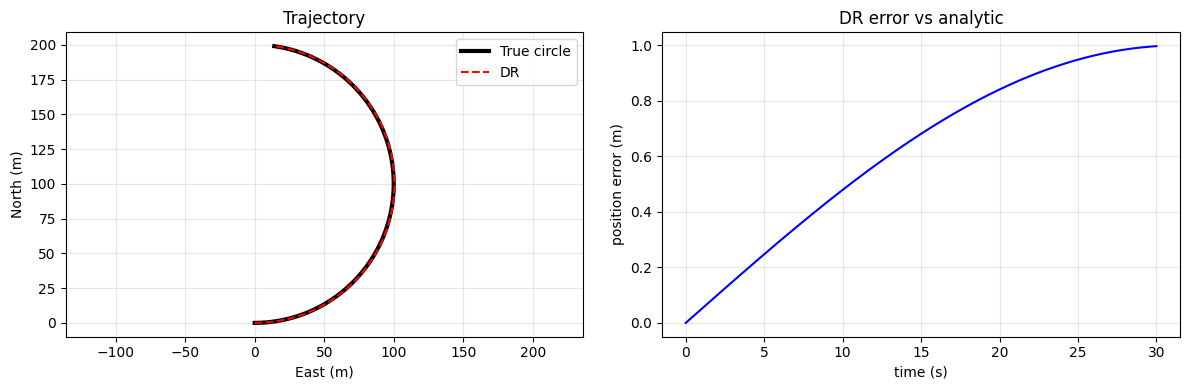

In [3]:
# Setup: circle of radius 100 m
v0 = 10.0
wz_const = 0.1
T = 30.0
dt = 0.1
N = int(T / dt) + 1
t = np.arange(N) * dt

# Analytic ground truth
r = v0 / wz_const
theta = wz_const * t
x_true = r * np.sin(theta)
y_true = r * (1.0 - np.cos(theta))

# Run the integrator with the IMU values that *should* produce this trajectory
ax_seq = np.zeros(N)
wz_seq = np.full(N, wz_const)
x_dr, y_dr, v_dr, yaw_dr = dead_reckon_unicycle(
    ax_seq, wz_seq, dt, x0=0, y0=0, v0=v0, yaw0=0)

# Compare
err = np.sqrt((x_dr - x_true)**2 + (y_dr - y_true)**2)
print(f"Final true position:    ({x_true[-1]:.3f}, {y_true[-1]:.3f})")
print(f"Final DR position:      ({x_dr[-1]:.3f},  {y_dr[-1]:.3f})")
print(f"Max error over run:     {err.max():.3f} m")
print(f"Final error:            {err[-1]:.3f} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_true, y_true, 'k-', linewidth=3, label='True circle')
axes[0].plot(x_dr, y_dr, 'r--', linewidth=1.5, label='DR')
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')
axes[0].axis('equal'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Trajectory')
axes[1].plot(t, err, 'b-')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('position error (m)')
axes[1].set_title('DR error vs analytic'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The 1 m of error is purely the cost of Euler integration on curves — a well-understood numerical artifact

## Section 2: Bias propagation
a tiny constant bias in ax produces a position error that grows quadratically with time. This is why IMU dead-reckoning fails over long outages. This is why your PINN's job is fundamentally to estimate bias.

If your accelerometer has a constant bias b (so it reads ax_measured = ax_true + b), and you trust the reading and integrate it:

- After time t, your velocity error is b · t. (Linear growth.)
- Position is the integral of velocity, so position error is ½ · b · t². (Quadratic growth.)

---
- b = 0.05 m/s² (very small — entry-level MEMS IMU spec): error at 30 s is ½·0.05·900 = 22 m
- b = 0.10 m/s² (typical of cheap IMU): error at 30 s is 45 m

bias    time    theory (m)    measured (m)  
--------------------------------------------
0.05    5.0     0.625         0.613         
0.05    15.0    5.625         5.588         
0.05    30.0    22.500        22.425        
0.1     5.0     1.250         1.225         
0.1     15.0    11.250        11.175        
0.1     30.0    45.000        44.850        
0.2     5.0     2.500         2.450         
0.2     15.0    22.500        22.350        
0.2     30.0    90.000        89.700        


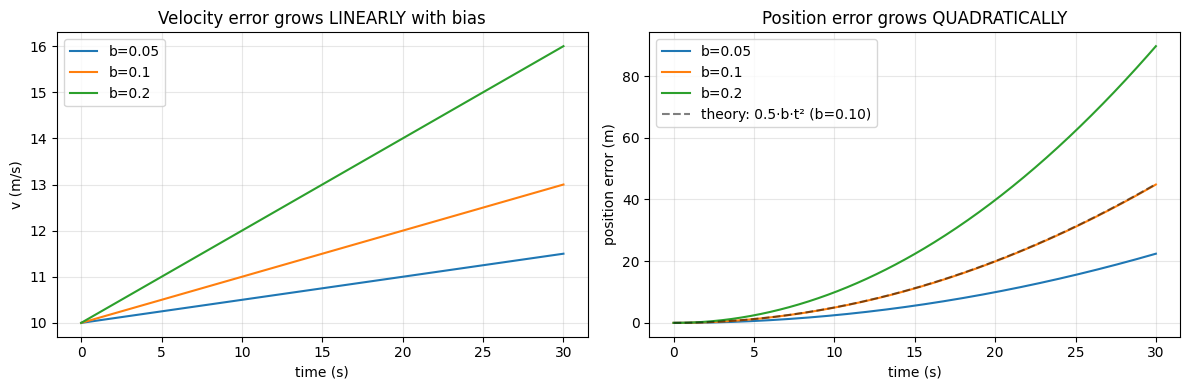

In [4]:
# Drive in a straight line at 10 m/s for 30 s. True ax = 0, wz = 0.
T = 30.0; dt = 0.1; N = int(T / dt) + 1
t = np.arange(N) * dt
v0 = 10.0
wz_seq = np.zeros(N)

# True trajectory: just x = v0 * t
x_true = v0 * t
y_true = np.zeros(N)

biases = [0.05, 0.10, 0.20]

print(f"{'bias':<8}{'time':<8}{'theory (m)':<14}{'measured (m)':<14}")
print('-' * 44)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for b in biases:
    ax_biased = np.full(N, b)
    x_dr, y_dr, v_dr, _ = dead_reckon_unicycle(
        ax_biased, wz_seq, dt, x0=0, y0=0, v0=v0, yaw0=0)
    err = np.sqrt((x_dr - x_true)**2 + (y_dr - y_true)**2)
    
    for tc in [5.0, 15.0, 30.0]:
        k = int(tc / dt)
        theory = 0.5 * b * tc**2
        print(f"{b:<8}{tc:<8}{theory:<14.3f}{err[k]:<14.3f}")
    
    axes[0].plot(t, v_dr, label=f'b={b}')
    axes[1].plot(t, err, label=f'b={b}')

# Overlay theory curve
t_th = np.linspace(0, T, 200)
axes[1].plot(t_th, 0.5 * 0.10 * t_th**2, 'k--', alpha=0.5, label='theory: 0.5·b·t² (b=0.10)')

axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('v (m/s)')
axes[0].set_title('Velocity error grows LINEARLY with bias'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('position error (m)')
axes[1].set_title('Position error grows QUADRATICALLY'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

This is the entire reason the project exists. Will's system uses a camera (no double-integration) plus an HGO (kinematics-based, no IMU). Both avoid the quadratic-error trap. the project asks: can a learned model estimate the bias well enough to recover the IMU's lost accuracy? The headline number from this plot — 45 m drift in 30 s from a 0.1 m/s² bias — is what you're trying to bring down.

This also tells us what to look for in PINN training. If your PINN is doing its job, when we plot its position error vs time during an outage, the curve should look much more linear (residual white-noise drift) than quadratic (residual bias drift). If it's still quadratic, the bias is still there — the PINN didn't learn to estimate it.

## Section 3: Loading multiple KITTI drives
A neural network trained on one drive learns that drive's specific quirks: 
- the specific bias realization in the synthetic noise,
- the specific street layout,
- the specific speed profile.
It will look brilliant on that drive and fall apart on any other.

The fix: train on many drives, evaluate on a drive the model has never seen

first from all the drives, extract 
- lat (deg), 
- lon (deg), 
- yaw_gt (rad) true heading (0 = east, increases counter-clockwise), 
- v_gt (m/s) true forward speed,
   
- ax (m/s²) forward accel, body frame, gravity-compensated. 
- ay (m/s²) sideways accel, body frame, gravity-compensated
- wz (rad/s) yaw rate

In [5]:
KITTI_ROOT = "/kaggle/input/datasets/rezamj/kitti-raw"

# Find all "drive_XXXX_sync" folders. They might be at depth 1 or depth 2
# depending on how the dataset was uploaded.
drives_found = []
for root, dirs, files in os.walk(KITTI_ROOT):
    for d in dirs:
        if "drive_" in d and "_sync" in d:
            full = os.path.join(root, d)
            # Only keep if it actually contains oxts/data
            # (we'll filter further with the loader)
            drives_found.append((d, full))

print(drives_found)

[('2011_10_03_drive_0027_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_10_03_drive_0027_sync'), ('2011_10_03_drive_0034_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_10_03_drive_0034_sync'), ('2011_09_30_drive_0016_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0016_sync'), ('2011_09_30_drive_0033_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0033_sync'), ('2011_09_30_drive_0020_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0020_sync'), ('2011_09_30_drive_0028_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0028_sync'), ('2011_09_30_drive_0034_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0034_sync'), ('2011_09_30_drive_0018_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0018_sync'), ('2011_09_30_drive_0027_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0027_sync'), ('2011_10_03_drive_0042_sync', '/kaggle/input/datasets/rezamj/kitti-raw/2011_10_0

In [6]:
seen = {}
for name, path in drives_found:
    if name not in seen:
        seen[name] = path

print(f"Found {len(seen)} unique drive folders:")
for name, path in sorted(seen.items()):
    print(f"  {name}  →  {path}")

Found 10 unique drive folders:
  2011_09_30_drive_0016_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0016_sync
  2011_09_30_drive_0018_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0018_sync
  2011_09_30_drive_0020_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0020_sync
  2011_09_30_drive_0027_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0027_sync
  2011_09_30_drive_0028_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0028_sync
  2011_09_30_drive_0033_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0033_sync
  2011_09_30_drive_0034_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_09_30_drive_0034_sync
  2011_10_03_drive_0027_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_10_03_drive_0027_sync
  2011_10_03_drive_0034_sync  →  /kaggle/input/datasets/rezamj/kitti-raw/2011_10_03_drive_0034_sync
  2011_10_03_drive_0042_sync  →  /kaggle/input/datasets/rezamj/kitti-

In [7]:
# Column indices in OXTS data files
F_LAT, F_LON = 0, 1
F_YAW = 5
F_VF = 8
F_AX_BODY = 14
F_AY_BODY = 15
F_WZ = 22

R_EARTH = 6_378_137.0  # WGS-84 equatorial radius, meters


def load_drive(drive_root):
    """
    Load a single KITTI drive into a DataFrame.

    drive_root : path to the folder named like "2011_09_30_drive_0016_sync"
                 (the OUTERMOST one — we handle the double-nesting inside)

    Returns:
        df : DataFrame with columns
             t, dt, ax, ay, wz, x_gt, y_gt, yaw_gt, v_gt
        meta : dict with summary stats
    """
    # Find the innermost oxts/data folder (handles the double-nesting)
    candidates = []
    for root, dirs, files in os.walk(drive_root):
        if root.endswith("oxts/data") or root.endswith("oxts\\data"):
            candidates.append(root)
    if not candidates:
        raise FileNotFoundError(f"No oxts/data folder found under {drive_root}")
    # Pick the deepest one (in case there are multiple)
    data_dir = max(candidates, key=len)
    oxts_dir = os.path.dirname(data_dir)
    ts_file = os.path.join(oxts_dir, "timestamps.txt")

    # 1. Read all OXTS files (one per timestep)
    files = sorted(glob.glob(os.path.join(data_dir, "*.txt")))
    if len(files) == 0:
        raise FileNotFoundError(f"No .txt files in {data_dir}")
    rows = []
    for f in files:
        vals = np.loadtxt(f)
        rows.append([vals[F_LAT], vals[F_LON], vals[F_YAW],
                     vals[F_VF],  vals[F_AX_BODY], vals[F_AY_BODY], vals[F_WZ]])
    raw = np.array(rows)

    # 2. Parse timestamps -> seconds since drive start
    with open(ts_file) as fh:
        ts_strings = [ln.strip() for ln in fh if ln.strip()]
    # KITTI timestamps include nanoseconds; truncate to microseconds
    ts_dt = [datetime.strptime(s[:26], "%Y-%m-%d %H:%M:%S.%f") for s in ts_strings]
    t_sec = np.array([(t - ts_dt[0]).total_seconds() for t in ts_dt])
    if len(t_sec) != len(raw):
        raise ValueError(f"Timestamp count {len(t_sec)} != OXTS file count {len(raw)}")

    # 3. Convert lat/lon -> local meters (origin = first sample of THIS drive)
    lat0 = np.deg2rad(raw[0, 0])
    lon0 = np.deg2rad(raw[0, 1])
    lat = np.deg2rad(raw[:, 0])
    lon = np.deg2rad(raw[:, 1])
    x_gt = R_EARTH * (lon - lon0) * np.cos(lat0)  # east
    y_gt = R_EARTH * (lat - lat0)                  # north

    # 4. Assemble DataFrame
    df = pd.DataFrame({
        "t":      t_sec,
        "dt":     np.concatenate([[0.0], np.diff(t_sec)]),
        "ax":     raw[:, 4],
        "ay":     raw[:, 5],
        "wz":     raw[:, 6],
        "x_gt":   x_gt,
        "y_gt":   y_gt,
        "yaw_gt": np.unwrap(raw[:, 2]),
        "v_gt":   raw[:, 3],
    })

    # 5. Summary metadata
    path_length = np.sum(np.sqrt(np.diff(x_gt)**2 + np.diff(y_gt)**2))
    meta = {
        "n_samples":   len(df),
        "duration_s":  float(t_sec[-1]),
        "mean_dt_ms":  float(np.mean(df["dt"][1:]) * 1000),
        "v_min":       float(df["v_gt"].min()),
        "v_max":       float(df["v_gt"].max()),
        "path_len_m":  float(path_length),
    }
    return df, meta


print("Loader defined")

Loader defined


In [8]:
drives = {}
metas = {}
for name, path in sorted(seen.items()):
    try:
        df, meta = load_drive(path)
        drives[name] = df
        metas[name] = meta
        print(f"  ✓ {name}: {meta['n_samples']:>5} samples, "
              f"{meta['duration_s']:>6.1f}s, "
              f"v_max={meta['v_max']:>5.2f} m/s, "
              f"path={meta['path_len_m']:>7.1f} m")
    except Exception as e:
        print(f"  ✗ {name}: FAILED — {e}")

print(f"\nLoaded {len(drives)} drives.")

  ✓ 2011_09_30_drive_0016_sync:   279 samples,   28.9s, v_max=15.71 m/s, path=  406.6 m
  ✓ 2011_09_30_drive_0018_sync:  2762 samples,  287.6s, v_max=11.65 m/s, path= 2205.7 m
  ✓ 2011_09_30_drive_0020_sync:  1104 samples,  114.5s, v_max=14.54 m/s, path= 1231.4 m
  ✓ 2011_09_30_drive_0027_sync:  1106 samples,  114.8s, v_max=11.53 m/s, path=  691.9 m
  ✓ 2011_09_30_drive_0028_sync:  5177 samples,  537.8s, v_max=12.33 m/s, path= 4129.7 m
  ✓ 2011_09_30_drive_0033_sync:  1594 samples,  165.3s, v_max=14.80 m/s, path= 1705.4 m
  ✓ 2011_09_30_drive_0034_sync:  1224 samples,  126.9s, v_max=14.59 m/s, path=  919.8 m
  ✓ 2011_10_03_drive_0027_sync:  4544 samples,  470.8s, v_max=12.85 m/s, path= 3722.6 m
  ✓ 2011_10_03_drive_0034_sync:  4663 samples,  483.5s, v_max=14.85 m/s, path= 5061.5 m
  ✓ 2011_10_03_drive_0042_sync:  1170 samples,  121.2s, v_max=26.40 m/s, path= 2589.1 m

Loaded 10 drives.


### visualize all drive trajectories side by side and select train + test drives 

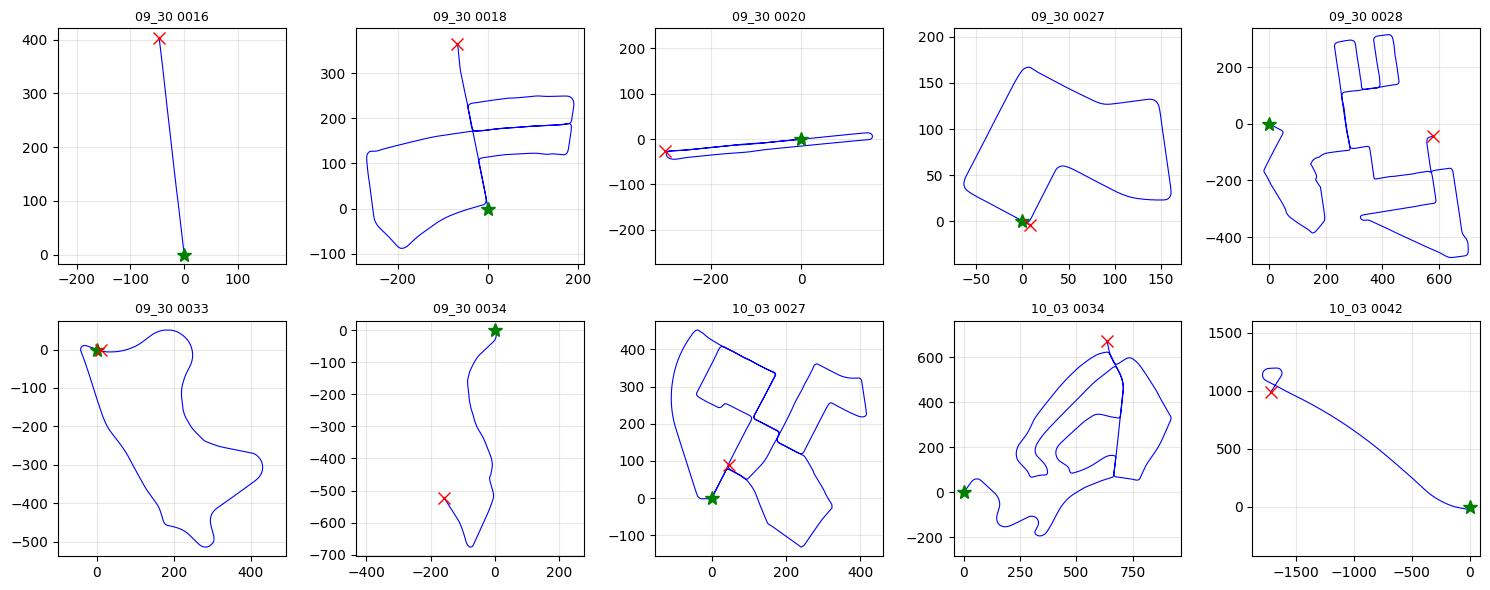

In [9]:
n = len(drives)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()
for i, (name, df) in enumerate(sorted(drives.items())):
    ax = axes[i]
    ax.plot(df["x_gt"], df["y_gt"], 'b-', linewidth=0.8)
    ax.plot(df["x_gt"].iloc[0], df["y_gt"].iloc[0], 'g*', markersize=10)
    ax.plot(df["x_gt"].iloc[-1], df["y_gt"].iloc[-1], 'rx', markersize=8)
    ax.set_title(name.replace("2011_", "").replace("_drive_", " ").replace("_sync", ""),
                 fontsize=9)
    ax.axis('equal'); ax.grid(alpha=0.3)
for j in range(n, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

### fixing yaw issue
KITTI's yaw_gt is stored in [-π, +π]. When the car's heading crosses the boundary, the stored number jumps by 2π — but the car didn't physically jump. It's a representation artifact

Sanity-checking on 2011_09_30_drive_0028_sync, 5177 samples


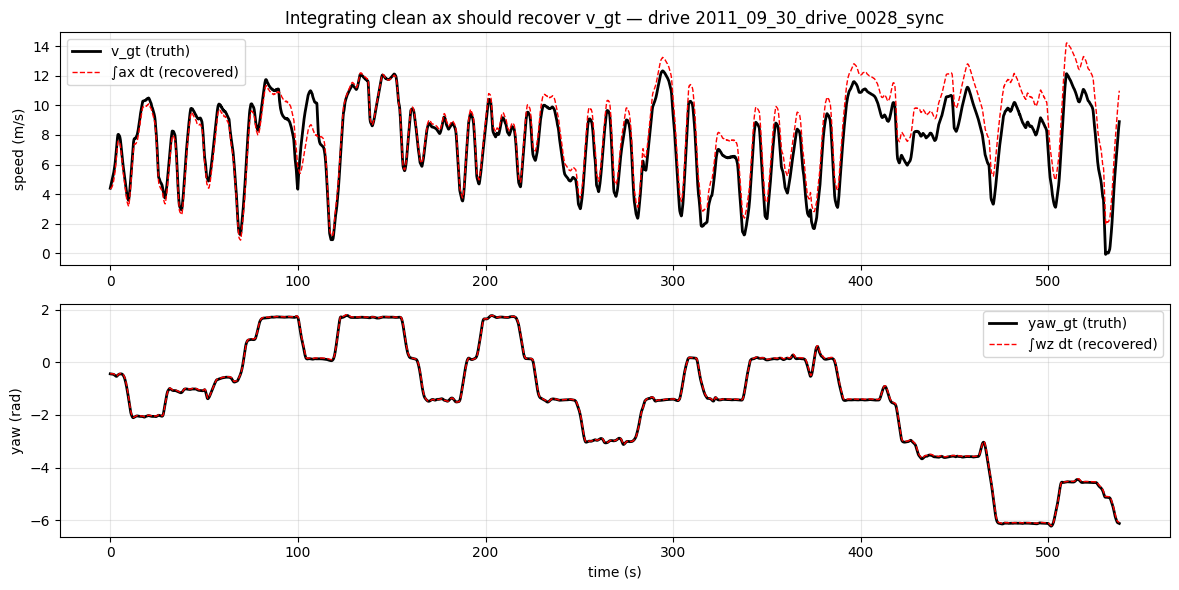


v:  max abs error = 2.430 m/s,  mean = 0.942 m/s
yaw: max abs error = 0.090 rad,  mean = 0.023 rad


In [10]:
# Pick the longest drive for this test (more data = clearer signal)
longest = max(drives.keys(), key=lambda k: metas[k]["n_samples"])

#longest = "2011_09_30_drive_0027_sync"
df = drives[longest]
print(f"Sanity-checking on {longest}, {len(df)} samples")

t = df["t"].values
dt = np.concatenate([[df["dt"].iloc[1]], df["dt"].values[1:]])  # use real per-step dt

# Integrate ax to get v_recovered (start from true v at t=0)
ax_clean = df["ax"].values
v_recovered = np.zeros(len(df))
v_recovered[0] = df["v_gt"].iloc[0]
for k in range(len(df) - 1):
    v_recovered[k+1] = v_recovered[k] + ax_clean[k] * dt[k+1]

# Integrate wz to get yaw_recovered (start from true yaw at t=0)
wz_clean = df["wz"].values
yaw_recovered = np.zeros(len(df))
yaw_recovered[0] = df["yaw_gt"].iloc[0]
for k in range(len(df) - 1):
    yaw_recovered[k+1] = yaw_recovered[k] + wz_clean[k] * dt[k+1]

# Plot side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, df["v_gt"], 'k-', linewidth=2, label='v_gt (truth)')
axes[0].plot(t, v_recovered, 'r--', linewidth=1, label='∫ax dt (recovered)')
axes[0].set_ylabel('speed (m/s)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(f'Integrating clean ax should recover v_gt — drive {longest}')

axes[1].plot(t, df["yaw_gt"], 'k-', linewidth=2, label='yaw_gt (truth)')
axes[1].plot(t, yaw_recovered, 'r--', linewidth=1, label='∫wz dt (recovered)')
axes[1].set_ylabel('yaw (rad)'); axes[1].set_xlabel('time (s)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Numerical comparison
v_err = np.abs(v_recovered - df["v_gt"].values)
yaw_err = np.abs(yaw_recovered - df["yaw_gt"].values)
print(f"\nv:  max abs error = {v_err.max():.3f} m/s,  mean = {v_err.mean():.3f} m/s")
print(f"yaw: max abs error = {yaw_err.max():.3f} rad,  mean = {yaw_err.mean():.3f} rad")

In [11]:
all_dts = np.concatenate([drives[k]["dt"].values[1:] for k in drives])
print(f"dt across all drives:")
print(f"  min:  {all_dts.min()*1000:.1f} ms")
print(f"  mean: {all_dts.mean()*1000:.1f} ms")
print(f"  max:  {all_dts.max()*1000:.1f} ms")
print(f"  std:  {all_dts.std()*1000:.1f} ms")

dt across all drives:
  min:  70.0 ms
  mean: 103.8 ms
  max:  130.1 ms
  std:  4.9 ms


### selecting drives

In [12]:
# Score every loaded drive on a few practical metrics
scorecard_rows = []
for name, df in sorted(drives.items()):
    duration   = df["t"].iloc[-1]
    n_samples  = len(df)
    v_mean     = df["v_gt"].mean()
    v_max      = df["v_gt"].max()
    v_min      = df["v_gt"].min()
    path_len   = np.sum(np.sqrt(np.diff(df["x_gt"])**2 + np.diff(df["y_gt"])**2))
    frac_stopped = (df["v_gt"] < 0.5).mean()  # fraction of samples below 0.5 m/s

    # Total turning = how many radians the car rotated through (unwrapped)
    yaw_unwrapped = np.unwrap(df["yaw_gt"].values)
    total_turning = abs(yaw_unwrapped[-1] - yaw_unwrapped[0])

    # Practical character label (heuristic)
    if v_mean < 3:        character = "slow / lots of stops"
    elif v_max < 12:      character = "city"
    elif v_max < 20:      character = "mixed"
    else:                 character = "highway"

    scorecard_rows.append({
        "drive": name,
        "samples": n_samples,
        "duration_s": round(duration, 1),
        "v_mean": round(v_mean, 2),
        "v_max": round(v_max, 2),
        "path_m": round(path_len, 1),
        "stopped_%": round(100 * frac_stopped, 1),
        "turning_rad": round(total_turning, 2),
        "character": character,
    })

scorecard = pd.DataFrame(scorecard_rows)
print(scorecard.to_string(index=False))

                     drive  samples  duration_s  v_mean  v_max  path_m  stopped_%  turning_rad character
2011_09_30_drive_0016_sync      279        28.9   14.02  15.71   406.6        0.0         0.00     mixed
2011_09_30_drive_0018_sync     2762       287.6    7.67  11.65  2205.7        2.7         0.05      city
2011_09_30_drive_0020_sync     1104       114.5   10.78  14.54  1231.4        0.0         6.29     mixed
2011_09_30_drive_0027_sync     1106       114.8    6.02  11.53   691.9        7.7         6.47      city
2011_09_30_drive_0028_sync     5177       537.8    7.65  12.33  4129.7        0.5         5.69     mixed
2011_09_30_drive_0033_sync     1594       165.3   10.32  14.80  1705.4        0.0         5.95     mixed
2011_09_30_drive_0034_sync     1224       126.9    7.24  14.59   919.8        3.8         3.85     mixed
2011_10_03_drive_0027_sync     4544       470.8    7.90  12.85  3722.6        0.4         6.33     mixed
2011_10_03_drive_0034_sync     4663       483.5   10.47

In [13]:
# === EDIT THIS BASED ON WHAT YOU SAW ===

# Drives to KEEP for train+val. Comment out any you don't want.
KEEP_DRIVES = [
   # "2011_09_30_drive_0016_sync", # too shortto divide to windows
    "2011_09_30_drive_0018_sync",
    "2011_09_30_drive_0020_sync",
    "2011_09_30_drive_0027_sync",
    "2011_09_30_drive_0028_sync", 
    "2011_09_30_drive_0033_sync",
    #"2011_09_30_drive_0034_sync",
    "2011_10_03_drive_0027_sync",
    "2011_10_03_drive_0034_sync",
    "2011_10_03_drive_0042_sync",  # this one is held out, see below
]

# Held-out drive (NEVER trained on, evaluation only)
HELD_OUT_NAME = "2011_09_30_drive_0034_sync"

# === END EDIT ===

# Validate the selection
assert HELD_OUT_NAME in drives, f"Held-out drive {HELD_OUT_NAME} not loaded"
assert HELD_OUT_NAME not in KEEP_DRIVES, \
    "Held-out drive should NOT be in KEEP_DRIVES (that would leak it into training)"
for k in KEEP_DRIVES:
    assert k in drives, f"Train drive {k} not loaded"

train_val_drives = {k: drives[k] for k in KEEP_DRIVES}
held_out_df = drives[HELD_OUT_NAME]

print(f"=== HELD OUT (evaluation only): {HELD_OUT_NAME} ===")
print(f"   {len(held_out_df)} samples, {metas[HELD_OUT_NAME]['duration_s']:.1f} s, "
      f"v_max {metas[HELD_OUT_NAME]['v_max']:.1f} m/s")

print(f"\n=== Train + Val pool: {len(train_val_drives)} drives ===")
total_train_samples = sum(len(d) for d in train_val_drives.values())
total_train_seconds = sum(metas[k]['duration_s'] for k in KEEP_DRIVES)
for k in sorted(KEEP_DRIVES):
    print(f"   {k}  ({len(drives[k])} samples, "
          f"{metas[k]['duration_s']:.0f}s, "
          f"v_max {metas[k]['v_max']:.1f} m/s)")
print(f"\nTotal: {total_train_samples} samples ≈ {total_train_seconds:.0f} s "
      f"≈ {total_train_seconds/60:.1f} minutes of driving")

=== HELD OUT (evaluation only): 2011_09_30_drive_0034_sync ===
   1224 samples, 126.9 s, v_max 14.6 m/s

=== Train + Val pool: 8 drives ===
   2011_09_30_drive_0018_sync  (2762 samples, 288s, v_max 11.7 m/s)
   2011_09_30_drive_0020_sync  (1104 samples, 114s, v_max 14.5 m/s)
   2011_09_30_drive_0027_sync  (1106 samples, 115s, v_max 11.5 m/s)
   2011_09_30_drive_0028_sync  (5177 samples, 538s, v_max 12.3 m/s)
   2011_09_30_drive_0033_sync  (1594 samples, 165s, v_max 14.8 m/s)
   2011_10_03_drive_0027_sync  (4544 samples, 471s, v_max 12.9 m/s)
   2011_10_03_drive_0034_sync  (4663 samples, 483s, v_max 14.8 m/s)
   2011_10_03_drive_0042_sync  (1170 samples, 121s, v_max 26.4 m/s)

Total: 22120 samples ≈ 2296 s ≈ 38.3 minutes of driving


## Section 4: Windowing the dataset
A function window_drive(df, window_length_s, stride_s) that takes a drive's DataFrame and returns a list of dicts, where each dict is one window:

```
{
    "ax":     array of length N,    # accel sequence
    
    "wz":     array of length N,    # yaw rate sequence
    
    "dt":     array of length N,    # per-step dt
    
    "x_gt":   array of length N,    # ground truth east
    
    "y_gt":   array of length N,    # ground truth north
    
    "v_gt":   array of length N,
    
    "yaw_gt": array of length N,
    
    "x0":     scalar,                # initial state at window start
    
    "y0":     scalar,
    
    "v0":     scalar,
    
    "yaw0":   scalar,
    
    "drive":  str,                   # which drive this came from

    "start_t": scalar,               # when in the drive it started
}

In [14]:
WINDOW_LENGTH_S = 30.0    # window duration in seconds
STRIDE_S        = 20.0    # how far apart window starts are (in seconds)


def window_drive(df, window_length_s=WINDOW_LENGTH_S, stride_s=STRIDE_S):
    """
    Cut a drive into overlapping fixed-duration windows.

    Returns a list of dicts, one per window. Each dict carries everything
    needed to (a) integrate, (b) train on, (c) evaluate.
    """
    t = df["t"].values
    drive_duration = t[-1]
    if drive_duration < window_length_s:
        return []  # drive too short

    windows = []
    start_t = 0.0
    while start_t + window_length_s <= drive_duration:
        end_t = start_t + window_length_s
        # Find indices of samples falling in [start_t, end_t)
        mask = (t >= start_t) & (t < end_t)
        idx = np.where(mask)[0]
        if len(idx) < 10:   # too few samples in window, skip
            start_t += stride_s
            continue
        i0, i1 = idx[0], idx[-1] + 1   # half-open

        # Build window dict. Re-zero time so it starts at 0.
        w = {
            "t":      df["t"].values[i0:i1] - df["t"].values[i0],
            "dt":     df["dt"].values[i0:i1].copy(),
            "ax":     df["ax"].values[i0:i1].copy(),
            "ay":     df["ay"].values[i0:i1].copy(),
            "wz":     df["wz"].values[i0:i1].copy(),
            "x_gt":   df["x_gt"].values[i0:i1] - df["x_gt"].values[i0],
            "y_gt":   df["y_gt"].values[i0:i1] - df["y_gt"].values[i0],
            "yaw_gt": df["yaw_gt"].values[i0:i1].copy(),
            "v_gt":   df["v_gt"].values[i0:i1].copy(),
            "x0":     0.0,    # we re-zeroed position
            "y0":     0.0,
            "v0":     float(df["v_gt"].values[i0]),
            "yaw0":   float(df["yaw_gt"].values[i0]),
            "start_t_in_drive": start_t,
        }
        # Make dt[0] reflect the gap from the previous sample, but for our
        # purposes inside the window we treat dt[0] as the typical step.
        # Use the median to avoid edge artifacts.
        if w["dt"][0] == 0 or w["dt"][0] > 0.5:
            w["dt"][0] = float(np.median(df["dt"].values[max(0, i0-5):i0+5]))
        windows.append(w)
        start_t += stride_s
    return windows


print("Windowing function defined.")

Windowing function defined.


In [15]:
all_train_val_windows = []
for name in sorted(KEEP_DRIVES):
    wins = window_drive(train_val_drives[name])
    for w in wins:
        w["drive"] = name
    all_train_val_windows.extend(wins)
    print(f"  {name}: {len(wins)} windows")

held_out_windows = window_drive(held_out_df)
for w in held_out_windows:
    w["drive"] = HELD_OUT_NAME

print(f"\nTotal train+val windows: {len(all_train_val_windows)}")
print(f"Held-out windows:        {len(held_out_windows)}")
#print(all_train_val_windows)

  2011_09_30_drive_0018_sync: 13 windows
  2011_09_30_drive_0020_sync: 5 windows
  2011_09_30_drive_0027_sync: 5 windows
  2011_09_30_drive_0028_sync: 26 windows
  2011_09_30_drive_0033_sync: 7 windows
  2011_10_03_drive_0027_sync: 23 windows
  2011_10_03_drive_0034_sync: 23 windows
  2011_10_03_drive_0042_sync: 5 windows

Total train+val windows: 107
Held-out windows:        5


In [16]:
TRAIN_FRAC = 0.8

# Group windows by drive, then split each drive's windows 80/20 sequentially.
# Sequential split means: first 80% of a drive's windows = train, last 20% = val.
# This avoids leakage between train and val (overlapping windows would otherwise
# end up on both sides of the split).
train_windows = []
val_windows = []
for name in sorted(KEEP_DRIVES):
    wins = [w for w in all_train_val_windows if w["drive"] == name]
    n_train = int(len(wins) * TRAIN_FRAC)
    train_windows.extend(wins[:n_train])
    val_windows.extend(wins[n_train:])

print(f"train windows: {len(train_windows)}")
print(f"val windows:   {len(val_windows)}")
print(f"held-out windows (Phase 0 evaluation only): {len(held_out_windows)}")

train windows: 83
val windows:   24
held-out windows (Phase 0 evaluation only): 5


### sanity check 4a: visualize a few train windows

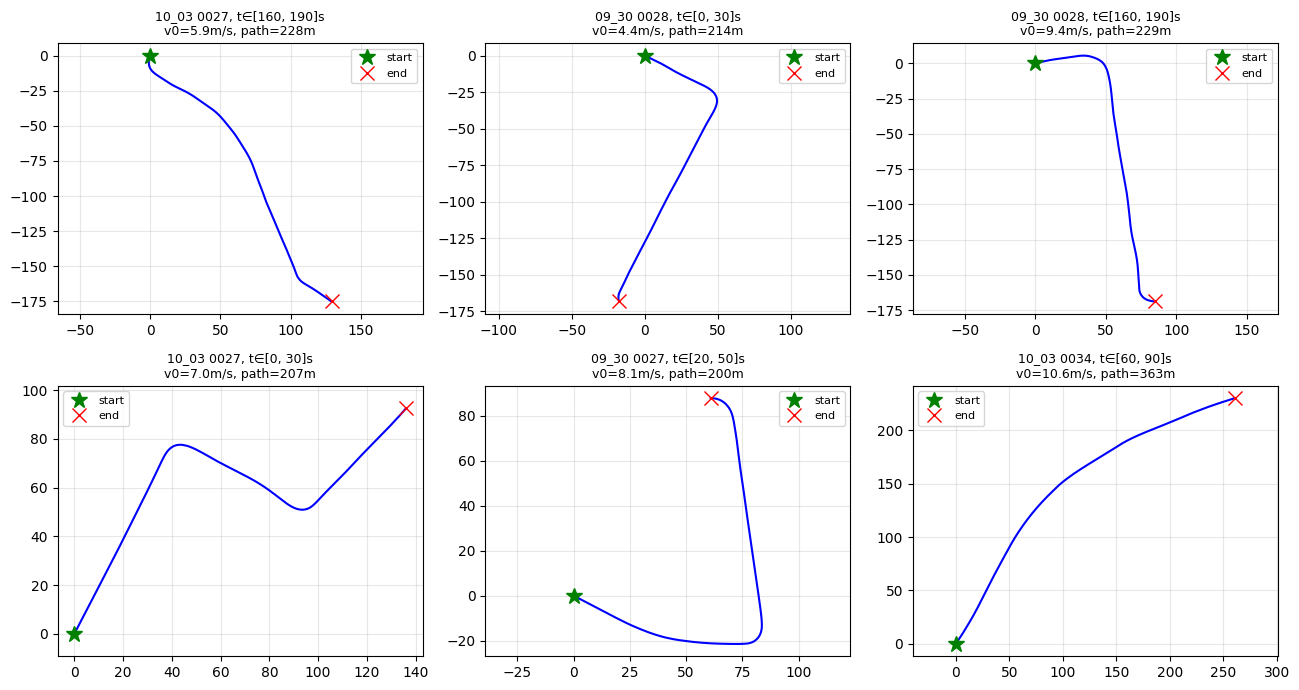

In [17]:
np.random.seed(7)
sample_idx = np.random.choice(len(train_windows), size=min(6, len(train_windows)), replace=False)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, idx in zip(axes.flatten(), sample_idx):
    w = train_windows[idx]
    ax.plot(w["x_gt"], w["y_gt"], 'b-', linewidth=1.5)
    ax.plot(0, 0, 'g*', markersize=12, label='start')
    ax.plot(w["x_gt"][-1], w["y_gt"][-1], 'rx', markersize=10, label='end')
    short_drive = w["drive"].replace("2011_", "").replace("_drive_", " ").replace("_sync", "")
    ax.set_title(f"{short_drive}, t∈[{w['start_t_in_drive']:.0f}, "
                 f"{w['start_t_in_drive']+WINDOW_LENGTH_S:.0f}]s\n"
                 f"v0={w['v0']:.1f}m/s, "
                 f"path={np.sum(np.sqrt(np.diff(w['x_gt'])**2 + np.diff(w['y_gt'])**2)):.0f}m",
                 fontsize=9)
    ax.axis('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Drive: 2011_09_30_drive_0018_sync, window starts at t=0.0s
Final position error (clean DR vs GT): 1.451 m
Max error during window:                1.601 m


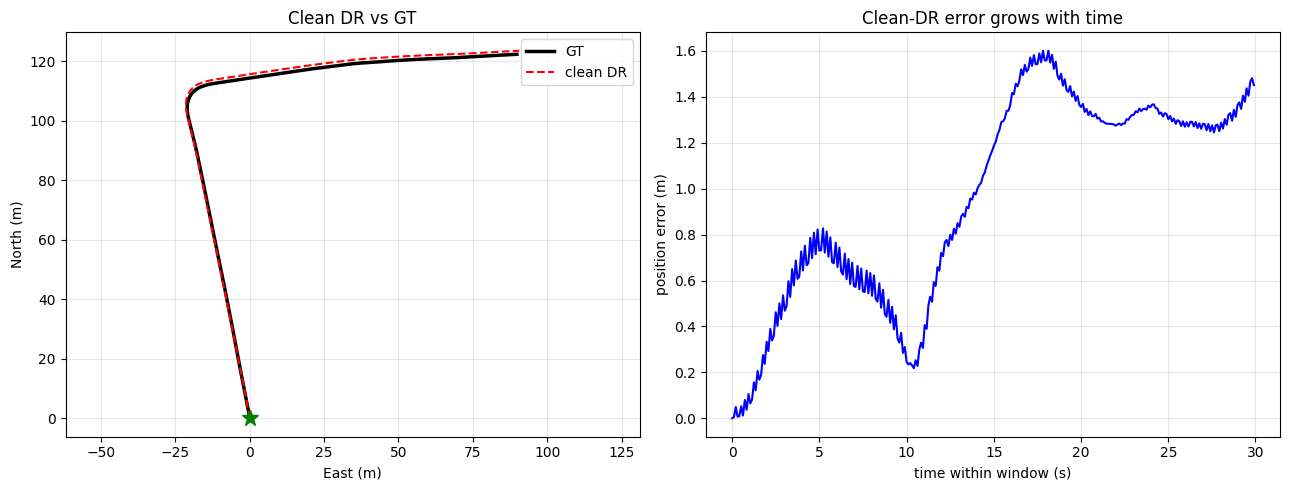

In [18]:
w = train_windows[0]
x_dr, y_dr, v_dr, yaw_dr = dead_reckon_unicycle(
    w["ax"], w["wz"], w["dt"],
    x0=w["x0"], y0=w["y0"], v0=w["v0"], yaw0=w["yaw0"]
)

err = np.sqrt((x_dr - w["x_gt"])**2 + (y_dr - w["y_gt"])**2)
print(f"Drive: {w['drive']}, window starts at t={w['start_t_in_drive']:.1f}s")
print(f"Final position error (clean DR vs GT): {err[-1]:.3f} m")
print(f"Max error during window:                {err.max():.3f} m")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(w["x_gt"], w["y_gt"], 'k-', linewidth=2.5, label='GT')
axes[0].plot(x_dr, y_dr, 'r--', linewidth=1.5, label='clean DR')
axes[0].plot(0, 0, 'g*', markersize=12)
axes[0].axis('equal'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')
axes[0].set_title('Clean DR vs GT')

axes[1].plot(w["t"], err, 'b-')
axes[1].set_xlabel('time within window (s)'); axes[1].set_ylabel('position error (m)')
axes[1].set_title('Clean-DR error grows with time')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The error should grow gradually with time, mostly from the small inconsistency between KITTI's ax and v_gt

In [19]:
def window_stats(name, windows):
    if len(windows) == 0:
        print(f"  {name}: 0 windows")
        return
    v0s = np.array([w["v0"] for w in windows])
    path_lens = np.array([np.sum(np.sqrt(np.diff(w["x_gt"])**2 + np.diff(w["y_gt"])**2))
                          for w in windows])
    print(f"  {name}: {len(windows)} windows | "
          f"v0 range [{v0s.min():.1f}, {v0s.max():.1f}] m/s, "
          f"path range [{path_lens.min():.0f}, {path_lens.max():.0f}] m")

print("Window split summary:")
window_stats("train   ", train_windows)
window_stats("val     ", val_windows)
window_stats("held-out", held_out_windows)

Window split summary:
  train   : 83 windows | v0 range [0.8, 26.0] m/s, path range [162, 769] m
  val     : 24 windows | v0 range [4.3, 23.2] m/s, path range [190, 509] m
  held-out: 5 windows | v0 range [1.1, 13.6] m/s, path range [216, 268] m


## Section 5: Bias-aware noise injection and the classical DR baseline
Three goals here, in order of importance:

1. Build a noise injection function that takes a clean window and produces a realistically noisy IMU sequence. This is what simulates "what if the car had a cheap MEMS IMU instead of KITTI's tactical-grade one."
2. Run the classical dead-reckoner on noisy windows across all our drives, with Monte Carlo. Each window gets simulated 30 times with different noise realizations, and we collect drift statistics. This gives us our baseline number — the curve our PINN must beat.
3. Confirm the baseline behaves consistently across drives. If drive A has 15 m drift and drive B has 80 m drift on the same noise model, something's wrong (probably with the drive or the noise scale). We want to see a roughly consistent pattern.

### Noise to be injected
1. White noise: Every sample is independently noisy. If you held a real accelerometer perfectly still, it would still wiggle around zero by some amount. This wiggle is mostly Gaussian and uncorrelated across samples.
2. Constant bias offset: The accelerometer's "zero" is not actually zero. It's offset by some fixed amount that depends on temperature, mounting, calibration, age, etc. model this as a single random number drawn at the start: b = sigma_bias_init * np.random.randn().

| Component    | Accel (ax, ay) | Gyro (wz) |
|--------------|----------------|-----------|
| White noise σ | 0.05 m/s²      | 0.01 rad/s (~-0.6°/s) |
| Initial bias σ | 0.10 m/s²      | 0.015 rad/s (~-0.9°/s) |

In [20]:
NOISE_PARAMS = dict(
    # White noise (per-sample, independent)
    sigma_wn_a   = 0.05,    # m/s^2  on ax, ay
    sigma_wn_w   = 0.01,    # rad/s  on wz

    # Initial constant bias (drawn once per window, applied to every sample)
    sigma_b0_a   = 0.10,    # m/s^2  on ax, ay
    sigma_b0_w   = 0.015,   # rad/s  on wz

    # Bias random walk (slow drift of bias over time)
    sigma_brw_a  = 0.001,   # m/s^2 per sqrt(s)
    sigma_brw_w  = 0.0002,  # rad/s per sqrt(s)
)



In [21]:

def inject_imu_noise(window, noise_params=NOISE_PARAMS, seed=None):
    """
    Apply a physically-motivated IMU noise model to a clean window.

    Returns a noisy COPY of (ax, ay, wz). The clean window is unmodified.
    """
    rng = np.random.default_rng(seed)
    N = len(window["ax"])
    dt = window["dt"]

    # 1. Initial constant biases (one number per window)
    b0_ax = noise_params["sigma_b0_a"] * rng.standard_normal()
    b0_ay = noise_params["sigma_b0_a"] * rng.standard_normal()
    b0_wz = noise_params["sigma_b0_w"] * rng.standard_normal()

    # 2. Bias random walk (slow drift on top of the initial bias)
    brw_ax_steps = noise_params["sigma_brw_a"] * np.sqrt(np.maximum(dt, 0.0)) * rng.standard_normal(N)
    brw_ay_steps = noise_params["sigma_brw_a"] * np.sqrt(np.maximum(dt, 0.0)) * rng.standard_normal(N)
    brw_wz_steps = noise_params["sigma_brw_w"] * np.sqrt(np.maximum(dt, 0.0)) * rng.standard_normal(N)
    brw_ax = np.cumsum(brw_ax_steps)
    brw_ay = np.cumsum(brw_ay_steps)
    brw_wz = np.cumsum(brw_wz_steps)

    # 3. White noise (independent per sample)
    wn_ax = noise_params["sigma_wn_a"] * rng.standard_normal(N)
    wn_ay = noise_params["sigma_wn_a"] * rng.standard_normal(N)
    wn_wz = noise_params["sigma_wn_w"] * rng.standard_normal(N)

    # 4. Combine
    ax_noisy = window["ax"] + b0_ax + brw_ax + wn_ax
    ay_noisy = window["ay"] + b0_ay + brw_ay + wn_ay
    wz_noisy = window["wz"] + b0_wz + brw_wz + wn_wz

    # Return everything (including the realized biases — useful for diagnostics)
    return {
        "ax": ax_noisy, "ay": ay_noisy, "wz": wz_noisy,
        "b0_ax": b0_ax, "b0_ay": b0_ay, "b0_wz": b0_wz,
    }


print("Noise injection function defined.")

Noise injection function defined.


### sanity check 5a: visualize noisy vs clean for one window

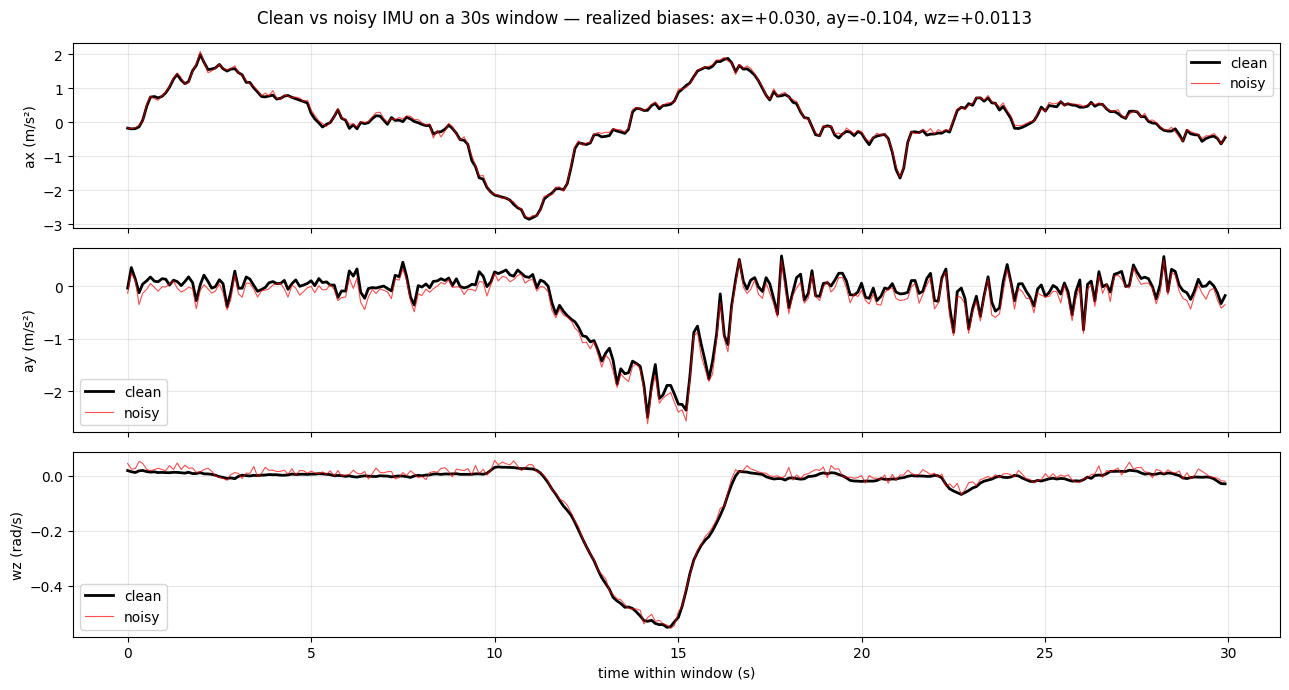

In [22]:
w = train_windows[0]
noisy = inject_imu_noise(w, seed=42)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
labels = [("ax", "m/s²"), ("ay", "m/s²"), ("wz", "rad/s")]
for i, (key, units) in enumerate(labels):
    axes[i].plot(w["t"], w[key], 'k-', linewidth=2, label='clean')
    axes[i].plot(w["t"], noisy[key], 'r-', linewidth=0.8, alpha=0.7, label='noisy')
    axes[i].set_ylabel(f"{key} ({units})")
    axes[i].legend(); axes[i].grid(alpha=0.3)
axes[-1].set_xlabel("time within window (s)")
plt.suptitle(f"Clean vs noisy IMU on a 30s window — "
             f"realized biases: ax={noisy['b0_ax']:+.3f}, "
             f"ay={noisy['b0_ay']:+.3f}, wz={noisy['b0_wz']:+.4f}")
plt.tight_layout(); plt.show()

### sanity check 5b: classical DR on the same window, clean vs noisy

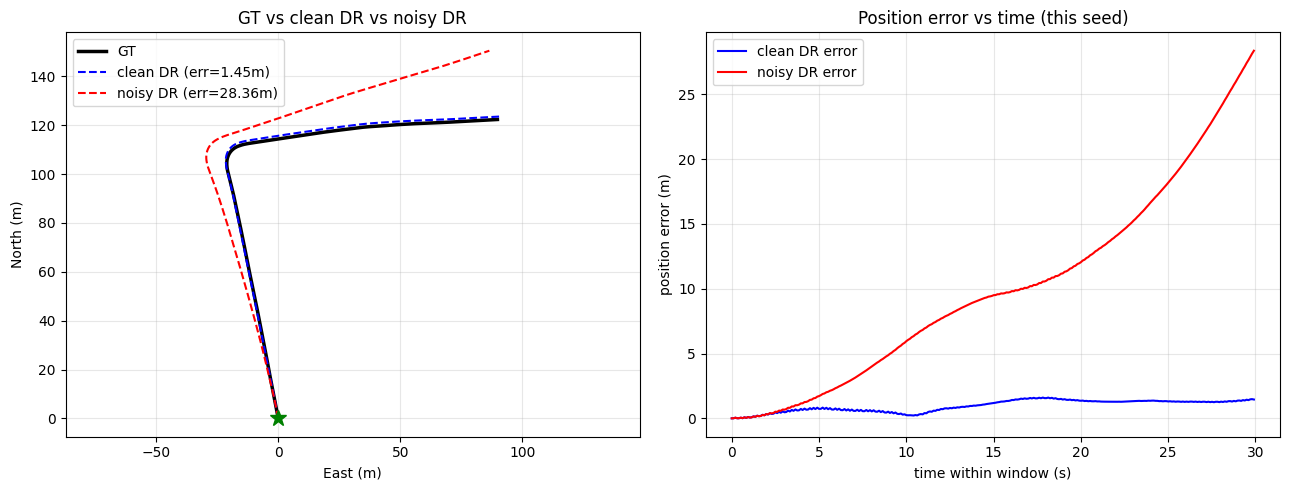

In [23]:


# Clean DR (truth-ish baseline)
x_c, y_c, _, _ = dead_reckon_unicycle(
    w["ax"], w["wz"], w["dt"],
    x0=w["x0"], y0=w["y0"], v0=w["v0"], yaw0=w["yaw0"]
)
# Noisy DR
x_n, y_n, _, _ = dead_reckon_unicycle(
    noisy["ax"], noisy["wz"], w["dt"],
    x0=w["x0"], y0=w["y0"], v0=w["v0"], yaw0=w["yaw0"]
)

err_clean = np.sqrt((x_c - w["x_gt"])**2 + (y_c - w["y_gt"])**2)
err_noisy = np.sqrt((x_n - w["x_gt"])**2 + (y_n - w["y_gt"])**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(w["x_gt"], w["y_gt"], 'k-', linewidth=2.5, label='GT')
axes[0].plot(x_c, y_c, 'b--', linewidth=1.5, label=f'clean DR (err={err_clean[-1]:.2f}m)')
axes[0].plot(x_n, y_n, 'r--', linewidth=1.5, label=f'noisy DR (err={err_noisy[-1]:.2f}m)')
axes[0].plot(0, 0, 'g*', markersize=12)
axes[0].axis('equal'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')
axes[0].set_title('GT vs clean DR vs noisy DR')

axes[1].plot(w["t"], err_clean, 'b-', label='clean DR error')
axes[1].plot(w["t"], err_noisy, 'r-', label='noisy DR error')
axes[1].set_xlabel('time within window (s)'); axes[1].set_ylabel('position error (m)')
axes[1].set_title('Position error vs time (this seed)')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

### Monte Carlo on a single window

Window: 2011_09_30_drive_0018_sync, t_start=0s
Final-time drift across 30 MC runs:
  mean: 49.98 m
  std:  24.32 m
  min:  16.98 m
  max:  114.88 m


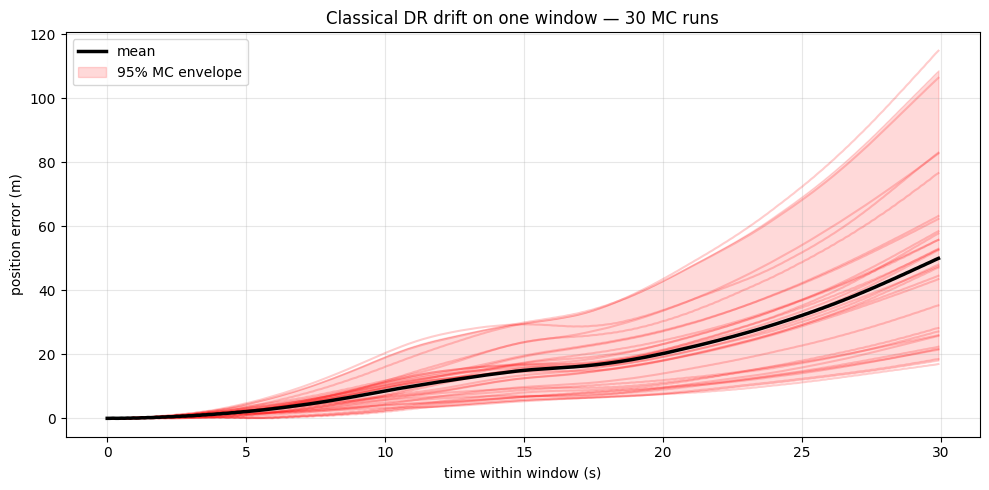

In [24]:
def monte_carlo_classical(window, n_runs=30, base_seed=10_000):
    """
    Run noisy classical DR many times on a single window.
    Returns:
      err_runs : (n_runs, N) array of position errors over time
    """
    N = len(window["ax"])
    err_runs = np.zeros((n_runs, N))
    for i in range(n_runs):
        noisy = inject_imu_noise(window, seed=base_seed + i)
        x_n, y_n, _, _ = dead_reckon_unicycle(
            noisy["ax"], noisy["wz"], window["dt"],
            x0=window["x0"], y0=window["y0"],
            v0=window["v0"], yaw0=window["yaw0"]
        )
        err_runs[i] = np.sqrt((x_n - window["x_gt"])**2 + (y_n - window["y_gt"])**2)
    return err_runs


# Try it on one window
w = train_windows[0]
err_runs = monte_carlo_classical(w, n_runs=30)
print(f"Window: {w['drive']}, t_start={w['start_t_in_drive']:.0f}s")
print(f"Final-time drift across 30 MC runs:")
print(f"  mean: {err_runs[:, -1].mean():.2f} m")
print(f"  std:  {err_runs[:, -1].std():.2f} m")
print(f"  min:  {err_runs[:, -1].min():.2f} m")
print(f"  max:  {err_runs[:, -1].max():.2f} m")

# Plot all 30 trajectories of the error
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(30):
    ax.plot(w["t"], err_runs[i], 'r-', alpha=0.2)
ax.plot(w["t"], err_runs.mean(axis=0), 'k-', linewidth=2.5, label='mean')
ax.fill_between(w["t"],
                np.percentile(err_runs, 2.5, axis=0),
                np.percentile(err_runs, 97.5, axis=0),
                alpha=0.15, color='red', label='95% MC envelope')
ax.set_xlabel('time within window (s)'); ax.set_ylabel('position error (m)')
ax.set_title(f'Classical DR drift on one window — 30 MC runs')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### Monte Carlo on all held-out windows

Running classical-DR Monte Carlo on 5 held-out windows...
  done 5/5

=== HELD-OUT BASELINE (classical DR with bias-aware noise) ===
  At  5s: mean drift =   1.98 m, 95% CI = [ 0.26,   4.56] m
  At 15s: mean drift =  14.98 m, 95% CI = [ 3.58,  34.63] m


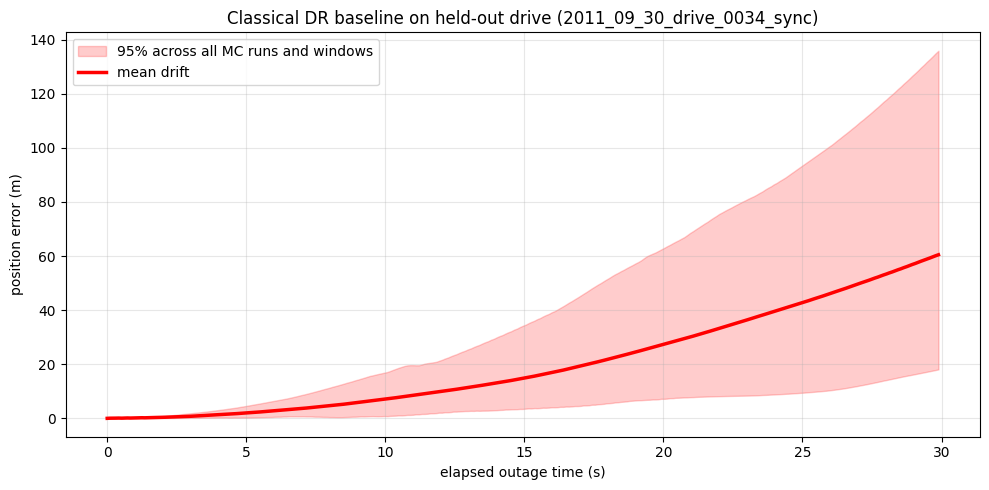


Saved classical-DR baseline. This is the curve our PINN must beat.


In [25]:
print(f"Running classical-DR Monte Carlo on {len(held_out_windows)} held-out windows...")
all_err_runs = []  # one (n_runs, N) array per window
for i, w in enumerate(held_out_windows):
    err_runs = monte_carlo_classical(w, n_runs=30)
    all_err_runs.append(err_runs)
    if (i+1) % 5 == 0:
        print(f"  done {i+1}/{len(held_out_windows)}")

# Aggregate across windows: for each timestep, what's the mean and CI of error?
# Pad to common length (windows can have slightly different N due to dt jitter)
min_N = min(e.shape[1] for e in all_err_runs)
all_err = np.concatenate([e[:, :min_N] for e in all_err_runs], axis=0)  # (n_windows*30, min_N)
t_common = held_out_windows[0]["t"][:min_N]

mean_err = all_err.mean(axis=0)
p2_err = np.percentile(all_err, 2.5, axis=0)
p97_err = np.percentile(all_err, 97.5, axis=0)

print(f"\n=== HELD-OUT BASELINE (classical DR with bias-aware noise) ===")
for t_check in [5, 15, 30]:
    if t_check <= t_common[-1]:
        k = np.argmin(np.abs(t_common - t_check))
        print(f"  At {t_check:>2}s: mean drift = {mean_err[k]:>6.2f} m, "
              f"95% CI = [{p2_err[k]:>5.2f}, {p97_err[k]:>6.2f}] m")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(t_common, p2_err, p97_err, alpha=0.2, color='red',
                label='95% across all MC runs and windows')
ax.plot(t_common, mean_err, 'r-', linewidth=2.5, label='mean drift')
ax.set_xlabel('elapsed outage time (s)')
ax.set_ylabel('position error (m)')
ax.set_title(f'Classical DR baseline on held-out drive ({HELD_OUT_NAME})')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Save for later comparison
import pickle
baseline = {
    "t": t_common,
    "mean_err": mean_err,
    "p2": p2_err,
    "p97": p97_err,
    "all_err": all_err,
}
print(f"\nSaved classical-DR baseline. This is the curve our PINN must beat.")

In [26]:
print("Mean 30s drift on a sample of windows from each train+val drive:")
for name in sorted(KEEP_DRIVES):
    drive_wins = [w for w in train_windows + val_windows if w["drive"] == name]
    if not drive_wins:
        continue
    sample = drive_wins[:min(5, len(drive_wins))]  # first 5 windows
    finals = []
    for w in sample:
        err_runs = monte_carlo_classical(w, n_runs=10)  # fewer runs for speed
        finals.append(err_runs[:, -1].mean())
    short = name.replace("2011_", "").replace("_drive_", " ").replace("_sync", "")
    print(f"  {short}: mean 30s drift = {np.mean(finals):>5.1f} m  "
          f"(across {len(sample)} windows × 10 MC runs)")

Mean 30s drift on a sample of windows from each train+val drive:
  09_30 0018: mean 30s drift =  53.3 m  (across 5 windows × 10 MC runs)
  09_30 0020: mean 30s drift =  80.2 m  (across 5 windows × 10 MC runs)
  09_30 0027: mean 30s drift =  52.5 m  (across 5 windows × 10 MC runs)
  09_30 0028: mean 30s drift =  63.6 m  (across 5 windows × 10 MC runs)
  09_30 0033: mean 30s drift =  70.9 m  (across 5 windows × 10 MC runs)
  10_03 0027: mean 30s drift =  51.7 m  (across 5 windows × 10 MC runs)
  10_03 0034: mean 30s drift =  69.7 m  (across 5 windows × 10 MC runs)
  10_03 0042: mean 30s drift = 151.5 m  (across 5 windows × 10 MC runs)


# Section 6: The bias-aware physics loss
can a learned model estimate IMU bias well enough to recover the lost accuracy of a cheap IMU during GNSS outages?

A quick recap on old physics loss 
```
r1 = d_dt(x_pred)   - v_pred * cos(yaw_pred)
r2 = d_dt(y_pred)   - v_pred * sin(yaw_pred)
r3 = d_dt(v_pred)   - ax_raw
r4 = d_dt(yaw_pred) - wz_raw
```

Loss = mean of r1² + r2² + r3² + r4².

- r1, r2: "Whatever positions you output, their time derivative must equal v · cos(yaw) and v · sin(yaw) of your other outputs." This is a pure geometric/kinematic consistency constraint. It says nothing about the IMU. It says: your outputs must be self-consistent with the unicycle equations.
- r3: "Whatever velocity you output, its derivative must equal the raw IMU acceleration I gave you." Read this carefully. It's telling the network: your dv/dt has to track ax_raw exactly. But ax_raw is biased. So the network is being told: be biased, just like the IMU.
- r4: Same problem with yaw rate.

The data loss tells the network "your trajectory should match the GT trajectory." The physics loss r3/r4 tells it "but also, your derivatives should track the noisy IMU." These two pulls are in partial tension. The network finds a compromise that's better than pure integration but not by much. That's why your slide 18 only showed ~2× improvement instead of 5-10×.

The loss expressed: "trust the IMU." We need it to express: "the IMU has a bias, and your job is to figure out what the bias is."

### The bias head:


In [55]:
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


class BiasAwarePINN(nn.Module):
    """
    Same trunk as the old residual MLP, but with two heads:
      - trajectory head: outputs (dx, dy, dv, dyaw) per timestep, scaled by t
      - bias head: outputs (b_a, b_w) per timestep; we average over time to
                   produce a single (b_a, b_w) per window
    """
    def __init__(self, hidden=64, layers=4, n_inputs=7):
        super().__init__()
        # Trunk
        dims = [n_inputs] + [hidden] * layers
        trunk_mods = []
        for i in range(len(dims) - 1):
            trunk_mods.append(nn.Linear(dims[i], dims[i+1]))
            trunk_mods.append(nn.Tanh())
        self.trunk = nn.Sequential(*trunk_mods)

        # Trajectory head: 4 outputs (dx, dy, dv, dyaw)
        self.head_traj = nn.Linear(hidden, 4)

        # Bias head: 2 outputs (b_a, b_w) per timestep, averaged over window later
        self.head_bias = nn.Linear(hidden, 2)
        
        for m in self.trunk.modules():
            
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=5/3)  # 5/3 is the tanh gain
                nn.init.zeros_(m.bias)


    def forward(self, inp):
        """
        inp: (N, n_inputs)  — per-timestep input features
        Returns:
          traj_raw : (N, 4) — the trajectory deltas before scaling by t
          bias     : (2,)   — single bias for the whole window (mean over time)
        """
        h = self.trunk(inp)
        traj_raw = self.head_traj(h)
        bias_per_t = self.head_bias(h)
        bias = bias_per_t.mean(dim=0)  # (2,) — single bias for the whole window
        return traj_raw, bias


# Quick instantiation test
model = BiasAwarePINN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model created. Trainable params: {n_params}")

Using device: cuda
Model created. Trainable params: 13382


In [56]:
def compute_normalization(windows):
    """
    Compute mean and std for every feature across all windows.
    """
    all_ax = np.concatenate([w["ax"] for w in windows])
    all_ay = np.concatenate([w["ay"] for w in windows])
    all_wz = np.concatenate([w["wz"] for w in windows])
    all_x  = np.concatenate([w["x_gt"] for w in windows])
    all_y  = np.concatenate([w["y_gt"] for w in windows])
    all_v  = np.concatenate([w["v_gt"] for w in windows])
    all_yaw = np.concatenate([w["yaw_gt"] for w in windows])
    all_v0 = np.array([w["v0"] for w in windows])

    NORM = {
        "Sax_mean": float(all_ax.mean()), "Sax_std": float(all_ax.std() + 1e-6),
        "Say_mean": float(all_ay.mean()), "Say_std": float(all_ay.std() + 1e-6),
        "Swz_mean": float(all_wz.mean()), "Swz_std": float(all_wz.std() + 1e-6),
        "x_std":   float(all_x.std() + 1e-6),
        "y_std":   float(all_y.std() + 1e-6),
        "v_std":   float(all_v.std() + 1e-6),
        "yaw_std": float(all_yaw.std() + 1e-6),
        "v0_mean": float(all_v0.mean()), "v0_std": float(all_v0.std() + 1e-6),
        "t_scale": float(WINDOW_LENGTH_S),  # normalize time by window length
    }
    return NORM


NORM = compute_normalization(train_windows)
print("Normalization stats computed:")
for k, v in NORM.items():
    print(f"  {k}: {v:.4f}")

Normalization stats computed:
  Sax_mean: 0.0265
  Sax_std: 0.9210
  Say_mean: -0.0449
  Say_std: 1.0724
  Swz_mean: 0.0014
  Swz_std: 0.1733
  x_std: 114.2019
  y_std: 98.6673
  v_std: 4.3894
  yaw_std: 2.8747
  v0_mean: 8.6809
  v0_std: 4.4484
  t_scale: 30.0000


In [59]:
def build_input(window, noisy_imu, NORM):
    """
    Build the (N, 8) input tensor for the network.
    """
    N = len(window["ax"])
    t_norm = window["t"] / NORM["t_scale"]
    Sax_n = (noisy_imu["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"]
    Say_n = (noisy_imu["ay"] - NORM["Say_mean"]) / NORM["Say_std"]
    Swz_n = (noisy_imu["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"]
    
    
    v0_n  = np.full(N, (window["v0"] - NORM["v0_mean"]) / NORM["v0_std"])
    cos_yaw0 = np.full(N, np.cos(window["yaw0"]))
    sin_yaw0 = np.full(N, np.sin(window["yaw0"]))

    inp = np.stack([t_norm, Sax_n, Say_n, Swz_n, v0_n, cos_yaw0, sin_yaw0], axis=1)

    
    return torch.tensor(inp, dtype=torch.float32, device=DEVICE)


def build_target(window, NORM):
    """
    Build the (N, 4) target tensor — the trajectory we want the network to output,
    in NORMALIZED units. We compare network output to this.
    """
    N = len(window["ax"])
    # Normalize each component by its std
    target = np.stack([
        window["x_gt"] / NORM["x_std"],
        window["y_gt"] / NORM["y_std"],
        (window["v_gt"] - window["v0"]) / NORM["v_std"],   # delta from initial
        (window["yaw_gt"] - window["yaw0"]) / NORM["yaw_std"],  # delta from initial
    ], axis=1)
    return torch.tensor(target, dtype=torch.float32, device=DEVICE)


# Test build
w = train_windows[0]
noisy = inject_imu_noise(w, seed=0)
inp = build_input(w, noisy, NORM)
tgt = build_target(w, NORM)
print(f"Input tensor shape:  {inp.shape}  (expected ({len(w['ax'])}, 7))")
print(f"Target tensor shape: {tgt.shape}  (expected ({len(w['ax'])}, 4))")
print(f"Input mean per col: {inp.mean(dim=0).cpu().numpy()}")
print(f"Input std per col:  {inp.std(dim=0).cpu().numpy()}")

Input tensor shape:  torch.Size([288, 7])  (expected (288, 7))
Target tensor shape: torch.Size([288, 4])  (expected (288, 4))
Input mean per col: [ 0.49839714  0.06557374 -0.16836841 -0.2867148  -0.7262723  -0.17143495
  0.98519546]
Input std per col:  [0.28930578 1.06903    0.5439272  0.81442463 0.         0.
 0.        ]


In [60]:
def physics_loss_bias_aware(model, windows_batch, NORM, base_seed=0):
    """
    Compute physics + data + bias-regularization loss across a batch of windows.

    Returns:
      L_data, L_phys, L_bias_reg
    """
    L_data_total = 0.0
    L_phys_total = 0.0
    L_bias_total = 0.0

    for i, w in enumerate(windows_batch):
        # 1. Inject noise (re-injected each epoch, so the network sees new
        # noise realizations every time)
        noisy = inject_imu_noise(w, seed=base_seed + i)

        # 2. Build inputs and targets
        # Time tensor with grad enabled so we can take d_dt via autograd
        t = torch.tensor(w["t"] / NORM["t_scale"], dtype=torch.float32,
                         device=DEVICE, requires_grad=True).unsqueeze(1)
        N = t.shape[0]

        # Other input columns (no grad needed)
        Sax_n = torch.tensor((noisy["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)
        Say_n = torch.tensor((noisy["ay"] - NORM["Say_mean"]) / NORM["Say_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)
        Swz_n = torch.tensor((noisy["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)

        
        
        v0_n = torch.full((N, 1), (w["v0"] - NORM["v0_mean"]) / NORM["v0_std"],
                            dtype=torch.float32, device=DEVICE)
        cos_yaw0 = torch.full((N, 1), float(np.cos(w["yaw0"])),
                                dtype=torch.float32, device=DEVICE)
        sin_yaw0 = torch.full((N, 1), float(np.sin(w["yaw0"])),
                                dtype=torch.float32, device=DEVICE)
        v0_raw = torch.full((N, 1), w["v0"], dtype=torch.float32, device=DEVICE)
        yaw0_raw = torch.full((N, 1), w["yaw0"], dtype=torch.float32, device=DEVICE)

        inp = torch.cat([t, Sax_n, Say_n, Swz_n, v0_n, cos_yaw0, sin_yaw0], dim=1)

        
        # 3. Forward pass
        traj_raw, bias = model(inp)
        # Residual trick: outputs are scaled by t so prediction starts at zero
        pred = traj_raw * t

        # 4. Data loss (compared to NORMALIZED target)
        target = torch.tensor(np.stack([
            w["x_gt"] / NORM["x_std"],
            w["y_gt"] / NORM["y_std"],
            (w["v_gt"] - w["v0"]) / NORM["v_std"],
            (w["yaw_gt"] - w["yaw0"]) / NORM["yaw_std"],
        ], axis=1), dtype=torch.float32, device=DEVICE)
        L_data = ((pred - target) ** 2).mean()

        # 5. Physics loss (in PHYSICAL units, then we'll weight it)
        # Un-normalize predictions to physical units for the physics check
        x   = pred[:, 0:1] * NORM["x_std"]
        y   = pred[:, 1:2] * NORM["y_std"]
        dv  = pred[:, 2:3] * NORM["v_std"]
        dyaw = pred[:, 3:4] * NORM["yaw_std"]

        v_abs   = v0_raw + dv
        yaw_abs = yaw0_raw + dyaw

        # Take time derivatives via autograd
        def d_dt(field):
            grad = torch.autograd.grad(
                field, t,
                grad_outputs=torch.ones_like(field),
                create_graph=True, retain_graph=True
            )[0]
            return grad / NORM["t_scale"]   # divide by t_scale because t is normalized

        dx_pred   = d_dt(x)
        dy_pred   = d_dt(y)
        dv_pred   = d_dt(v_abs)
        dyaw_pred = d_dt(yaw_abs)

        ax_raw = torch.tensor(noisy["ax"], dtype=torch.float32, device=DEVICE).unsqueeze(1)
        wz_raw = torch.tensor(noisy["wz"], dtype=torch.float32, device=DEVICE).unsqueeze(1)

        # Bias correction (the heart of the change!)
        b_a = bias[0]
        b_w = bias[1]

        r1 = dx_pred   - v_abs * torch.cos(yaw_abs)
        r2 = dy_pred   - v_abs * torch.sin(yaw_abs)
        r3 = dv_pred   - (ax_raw - b_a)     # ← bias-corrected
        r4 = dyaw_pred - (wz_raw - b_w)     # ← bias-corrected

        L_phys = (r1 ** 2 + r2 ** 2 + r3 ** 2 + r4 ** 2).mean()
        L_bias_reg = b_a ** 2 + b_w ** 2

        L_data_total += L_data
        L_phys_total += L_phys
        L_bias_total += L_bias_reg

    n = len(windows_batch)
    return L_data_total / n, L_phys_total / n, L_bias_total / n


print("Bias-aware physics loss defined.")

Bias-aware physics loss defined.


In [61]:
model = BiasAwarePINN().to(DEVICE)
batch = train_windows[:2]  # tiny batch
L_data, L_phys, L_bias = physics_loss_bias_aware(model, batch, NORM, base_seed=0)

print(f"L_data:     {L_data.item():.6f}")
print(f"L_phys:     {L_phys.item():.6f}")
print(f"L_bias_reg: {L_bias.item():.6f}")

# Test that gradients flow
total = L_data + 0.1 * L_phys + 0.01 * L_bias
total.backward()

trunk_grad_norm = 0.0
for p in model.trunk.parameters():
    if p.grad is not None:
        trunk_grad_norm += p.grad.norm().item() ** 2
trunk_grad_norm = trunk_grad_norm ** 0.5

bias_head_grad_norm = 0.0
for p in model.head_bias.parameters():
    if p.grad is not None:
        bias_head_grad_norm += p.grad.norm().item() ** 2
bias_head_grad_norm = bias_head_grad_norm ** 0.5

print(f"\nGradient norms (must be > 0 if loss is differentiable):")
print(f"  trunk:     {trunk_grad_norm:.6f}")
print(f"  bias head: {bias_head_grad_norm:.6f}")

L_data:     0.344347
L_phys:     46.324135
L_bias_reg: 0.273857

Gradient norms (must be > 0 if loss is differentiable):
  trunk:     11.665840
  bias head: 0.286808


# Section 7: Training the new MLP and comparing to the old one

### the old physics loss

In [62]:
def physics_loss_old(model, windows_batch, NORM, base_seed=0):
    """
    The OLD physics loss — slide 16 version. No bias correction.
    The network here just doesn't use its bias head; we still call the same
    model but we ignore its bias output.

    This isolates the effect of the bias correction in the loss.
    """
    L_data_total = 0.0
    L_phys_total = 0.0

    for i, w in enumerate(windows_batch):
        noisy = inject_imu_noise(w, seed=base_seed + i)

        t = torch.tensor(w["t"] / NORM["t_scale"], dtype=torch.float32,
                         device=DEVICE, requires_grad=True).unsqueeze(1)
        N = t.shape[0]

        Sax_n = torch.tensor((noisy["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)
        Say_n = torch.tensor((noisy["ay"] - NORM["Say_mean"]) / NORM["Say_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)
        Swz_n = torch.tensor((noisy["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"],
                             dtype=torch.float32, device=DEVICE).unsqueeze(1)

        
        v0_n = torch.full((N, 1), (w["v0"] - NORM["v0_mean"]) / NORM["v0_std"],
                            dtype=torch.float32, device=DEVICE)
        cos_yaw0 = torch.full((N, 1), float(np.cos(w["yaw0"])),
                                dtype=torch.float32, device=DEVICE)
        sin_yaw0 = torch.full((N, 1), float(np.sin(w["yaw0"])),
                                dtype=torch.float32, device=DEVICE)
        v0_raw = torch.full((N, 1), w["v0"], dtype=torch.float32, device=DEVICE)
        yaw0_raw = torch.full((N, 1), w["yaw0"], dtype=torch.float32, device=DEVICE)

        inp = torch.cat([t, Sax_n, Say_n, Swz_n, v0_n, cos_yaw0, sin_yaw0], dim=1)

        
        traj_raw, _ = model(inp)  # Note: bias output ignored
        pred = traj_raw * t

        target = torch.tensor(np.stack([
            w["x_gt"] / NORM["x_std"],
            w["y_gt"] / NORM["y_std"],
            (w["v_gt"] - w["v0"]) / NORM["v_std"],
            (w["yaw_gt"] - w["yaw0"]) / NORM["yaw_std"],
        ], axis=1), dtype=torch.float32, device=DEVICE)
        L_data = ((pred - target) ** 2).mean()

        x   = pred[:, 0:1] * NORM["x_std"]
        y   = pred[:, 1:2] * NORM["y_std"]
        dv  = pred[:, 2:3] * NORM["v_std"]
        dyaw = pred[:, 3:4] * NORM["yaw_std"]
        v_abs   = v0_raw + dv
        yaw_abs = yaw0_raw + dyaw

        def d_dt(field):
            grad = torch.autograd.grad(field, t,
                grad_outputs=torch.ones_like(field),
                create_graph=True, retain_graph=True)[0]
            return grad / NORM["t_scale"]

        dx_pred   = d_dt(x)
        dy_pred   = d_dt(y)
        dv_pred   = d_dt(v_abs)
        dyaw_pred = d_dt(yaw_abs)

        ax_raw = torch.tensor(noisy["ax"], dtype=torch.float32, device=DEVICE).unsqueeze(1)
        wz_raw = torch.tensor(noisy["wz"], dtype=torch.float32, device=DEVICE).unsqueeze(1)

        # OLD residuals: no bias correction
        r1 = dx_pred   - v_abs * torch.cos(yaw_abs)
        r2 = dy_pred   - v_abs * torch.sin(yaw_abs)
        r3 = dv_pred   - ax_raw       # ← biased!
        r4 = dyaw_pred - wz_raw       # ← biased!

        L_phys = (r1 ** 2 + r2 ** 2 + r3 ** 2 + r4 ** 2).mean()

        L_data_total += L_data
        L_phys_total += L_phys

    n = len(windows_batch)
    return L_data_total / n, L_phys_total / n


print("Old physics loss defined (ablation reference).")

Old physics loss defined (ablation reference).


In [63]:
import time

def train_pinn(loss_type, train_windows, val_windows, NORM,
               n_epochs=2500, warmup=500, lambda_phys=0.1, lambda_bias_reg=0.01,
               batch_size=20, lr=1e-3, log_every=100):
    """
    Train a BiasAwarePINN with either 'old' or 'new' physics loss.

    Returns: model, history dict
    """
    assert loss_type in ("old", "new")
    print(f"\n=== Training with {loss_type.upper()} physics loss ===")
    print(f"   train: {len(train_windows)}w, val: {len(val_windows)}w")
    print(f"   epochs: {n_epochs}, warmup: {warmup}, lambda_phys: {lambda_phys}")
    if loss_type == "new":
        print(f"   lambda_bias_reg: {lambda_bias_reg}")

    model = BiasAwarePINN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"epoch": [], "L_data": [], "L_phys": [], "L_total": [],
               "val_drift_30s_mean": []}
    t0 = time.time()

    for ep in range(n_epochs):
        model.train()
        # Shuffle training windows
        idx = np.random.permutation(len(train_windows))[:batch_size]
        batch = [train_windows[i] for i in idx]
        seed_base = 100_000 + ep * 1000   # fresh noise every epoch

        if loss_type == "new":
            L_data, L_phys, L_bias_reg = physics_loss_bias_aware(
                model, batch, NORM, base_seed=seed_base)
            if ep < warmup:
                L = L_data
            else:
                L = L_data + lambda_phys * L_phys + lambda_bias_reg * L_bias_reg
        else:
            L_data, L_phys = physics_loss_old(
                model, batch, NORM, base_seed=seed_base)
            if ep < warmup:
                L = L_data
            else:
                L = L_data + lambda_phys * L_phys

        opt.zero_grad()
        L.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        # Periodic logging + val check
        if ep % log_every == 0 or ep == n_epochs - 1:
            history["epoch"].append(ep)
            history["L_data"].append(float(L_data.item()))
            history["L_phys"].append(float(L_phys.item()))
            history["L_total"].append(float(L.item()))

            # Quick val: drift on a few val windows
            val_drift = quick_val_drift(model, val_windows[:5], NORM)
            history["val_drift_30s_mean"].append(val_drift)

            if ep % (log_every * 5) == 0 or ep == n_epochs - 1:
                print(f"  ep {ep:5d}  L_data={float(L_data):.4f}  "
                      f"L_phys={float(L_phys):.4f}  "
                      f"val_30s_drift={val_drift:.2f}m")

    print(f"  done in {time.time()-t0:.1f}s")
    return model, history


def quick_val_drift(model, val_subset, NORM, n_seeds=3):
    """
    Quick eval: average final-time position error over a few val windows
    and a few noise seeds. Used during training to monitor progress.
    """
    model.eval()
    drifts = []
    with torch.no_grad():
        for w in val_subset:
            for s in range(n_seeds):
                noisy = inject_imu_noise(w, seed=999_000 + s)
                xp, yp = pinn_predict(model, w, noisy, NORM)
                drift_final = np.sqrt((xp[-1] - w["x_gt"][-1])**2 +
                                      (yp[-1] - w["y_gt"][-1])**2)
                drifts.append(drift_final)
    return float(np.mean(drifts))


def pinn_predict(model, window, noisy_imu, NORM):
    """
    Run the PINN on one window, return predicted (x, y) trajectory in meters.
    """
    N = len(window["ax"])
    t = torch.tensor(window["t"] / NORM["t_scale"], dtype=torch.float32,
                     device=DEVICE).unsqueeze(1)
    Sax_n = torch.tensor((noisy_imu["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"],
                         dtype=torch.float32, device=DEVICE).unsqueeze(1)
    Say_n = torch.tensor((noisy_imu["ay"] - NORM["Say_mean"]) / NORM["Say_std"],
                         dtype=torch.float32, device=DEVICE).unsqueeze(1)
    Swz_n = torch.tensor((noisy_imu["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"],
                         dtype=torch.float32, device=DEVICE).unsqueeze(1)
    
    
    v0_n = torch.full((N, 1), (window["v0"] - NORM["v0_mean"]) / NORM["v0_std"],
                        dtype=torch.float32, device=DEVICE)
    cos_yaw0 = torch.full((N, 1), float(np.cos(window["yaw0"])),
                            dtype=torch.float32, device=DEVICE)
    sin_yaw0 = torch.full((N, 1), float(np.sin(window["yaw0"])),
                            dtype=torch.float32, device=DEVICE)
    v0_raw = torch.full((N, 1), window["v0"], dtype=torch.float32, device=DEVICE)
    yaw0_raw = torch.full((N, 1), window["yaw0"], dtype=torch.float32, device=DEVICE)

    inp = torch.cat([t, Sax_n, Say_n, Swz_n, v0_n, cos_yaw0, sin_yaw0], dim=1)

    traj_raw, _ = model(inp)
    pred = traj_raw * t
    x = (pred[:, 0] * NORM["x_std"]).cpu().numpy()
    y = (pred[:, 1] * NORM["y_std"]).cpu().numpy()
    return x, y


print("Training and prediction utilities defined.")

Training and prediction utilities defined.


### pre-training sanity check

In [64]:
torch.manual_seed(42)
test_model = BiasAwarePINN().to(DEVICE)
test_batch = train_windows[:2]

# OLD loss
test_model.zero_grad()
L_d_o, L_p_o = physics_loss_old(test_model, test_batch, NORM, base_seed=0)
(L_d_o + 0.1 * L_p_o).backward()
g_old = torch.cat([
    (p.grad if p.grad is not None else torch.zeros_like(p)).flatten()
    for p in test_model.parameters()
])

# NEW loss — fresh model with same seed
torch.manual_seed(42)
test_model = BiasAwarePINN().to(DEVICE)
test_model.zero_grad()
L_d_n, L_p_n, L_b_n = physics_loss_bias_aware(test_model, test_batch, NORM, base_seed=0)
(L_d_n + 0.1 * L_p_n + 0.0001 * L_b_n).backward()
g_new = torch.cat([
    (p.grad if p.grad is not None else torch.zeros_like(p)).flatten()
    for p in test_model.parameters()
])

diff = (g_old - g_new).abs().mean().item()
print(f"Mean abs gradient difference between OLD and NEW: {diff:.6e}")
print(f"  (must be > ~1e-5 if losses are actually different)")

# Hidden-state variance across time — must be O(0.1) at least
torch.manual_seed(42)
test_model = BiasAwarePINN().to(DEVICE)
w = train_windows[0]
noisy = inject_imu_noise(w, seed=0)
N = len(w["ax"])
t = torch.tensor(w["t"] / NORM["t_scale"], dtype=torch.float32, device=DEVICE).unsqueeze(1)
Sax_n = torch.tensor((noisy["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"],
                     dtype=torch.float32, device=DEVICE).unsqueeze(1)
Say_n = torch.tensor((noisy["ay"] - NORM["Say_mean"]) / NORM["Say_std"],
                     dtype=torch.float32, device=DEVICE).unsqueeze(1)
Swz_n = torch.tensor((noisy["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"],
                     dtype=torch.float32, device=DEVICE).unsqueeze(1)




v0_n = torch.full((N, 1), (w["v0"] - NORM["v0_mean"]) / NORM["v0_std"],
                    dtype=torch.float32, device=DEVICE)
cos_yaw0 = torch.full((N, 1), float(np.cos(w["yaw0"])),
                        dtype=torch.float32, device=DEVICE)
sin_yaw0 = torch.full((N, 1), float(np.sin(w["yaw0"])),
                        dtype=torch.float32, device=DEVICE)
inp = torch.cat([t, Sax_n, Say_n, Swz_n, v0_n, cos_yaw0, sin_yaw0], dim=1)



with torch.no_grad():
    h = test_model.trunk(inp)
print(f"\nHidden state std across time (mean over neurons): {h.std(dim=0).mean().item():.4f}")
print(f"  (must be > ~0.1 for the network to produce time-varying outputs)")

Mean abs gradient difference between OLD and NEW: 6.942243e-04
  (must be > ~1e-5 if losses are actually different)

Hidden state std across time (mean over neurons): 0.3777
  (must be > ~0.1 for the network to produce time-varying outputs)


In [65]:

  # 1. Per-channel input stats
  print("inp shape:", inp.shape)            # expect (B, T, 6)
  print("inp mean per channel:", inp.mean(dim=(0,1)))
  print("inp std per channel:",  inp.std(dim=(0,1)))
  print("inp std *across time* per channel (mean over batch):",
        inp.std(dim=1).mean(dim=0))         # this is the key one

  # 2. Activation magnitude layer-by-layer
  x = inp
  for i, layer in enumerate(model.trunk):
      x = layer(x)
      if hasattr(layer, 'weight'):  # only print after Linear+activation pairs
          print(f"layer {i} out: mean={x.mean():.4f}  std={x.std():.4f}  "
                f"std_across_time={x.std(dim=1).mean():.4f}")



inp shape: torch.Size([288, 7])
inp mean per channel: tensor(0.0281, device='cuda:0')
inp std per channel: tensor(0.7621, device='cuda:0')
inp std *across time* per channel (mean over batch): tensor(0.7429, device='cuda:0')
layer 0 out: mean=0.0363  std=0.5111  std_across_time=0.4784
layer 2 out: mean=0.0663  std=0.7034  std_across_time=0.6769
layer 4 out: mean=0.1372  std=0.7972  std_across_time=0.7883
layer 6 out: mean=-0.0654  std=0.9406  std_across_time=0.9334


In [66]:
# Train with the OLD loss
np.random.seed(0); torch.manual_seed(0)
model_old, hist_old = train_pinn("old", train_windows, val_windows, NORM,
                                  n_epochs=2500, warmup=500, lambda_phys=0.1)

# Train with the NEW (bias-aware) loss
np.random.seed(0); torch.manual_seed(0)  # reset to same starting point
model_new, hist_new = train_pinn("new", train_windows, val_windows, NORM,
                                  n_epochs=2500, warmup=500,
                                  lambda_phys=0.1, lambda_bias_reg=0.0001)  # was 0.01


=== Training with OLD physics loss ===
   train: 83w, val: 24w
   epochs: 2500, warmup: 500, lambda_phys: 0.1
  ep     0  L_data=0.9163  L_phys=134.9618  val_30s_drift=218.11m
  ep   500  L_data=0.1899  L_phys=37.6459  val_30s_drift=133.89m
  ep  1000  L_data=0.2601  L_phys=1.3498  val_30s_drift=166.30m
  ep  1500  L_data=0.3515  L_phys=1.1525  val_30s_drift=173.92m
  ep  2000  L_data=0.2697  L_phys=1.2501  val_30s_drift=187.31m
  ep  2499  L_data=0.2765  L_phys=1.1439  val_30s_drift=191.28m
  done in 518.1s

=== Training with NEW physics loss ===
   train: 83w, val: 24w
   epochs: 2500, warmup: 500, lambda_phys: 0.1
   lambda_bias_reg: 0.0001
  ep     0  L_data=0.9163  L_phys=135.1185  val_30s_drift=218.11m
  ep   500  L_data=0.1899  L_phys=37.8510  val_30s_drift=133.89m
  ep  1000  L_data=0.2588  L_phys=1.3605  val_30s_drift=166.40m
  ep  1500  L_data=0.3588  L_phys=1.0181  val_30s_drift=172.68m
  ep  2000  L_data=0.2710  L_phys=1.2278  val_30s_drift=176.37m
  ep  2499  L_data=0.276

### training loss curves

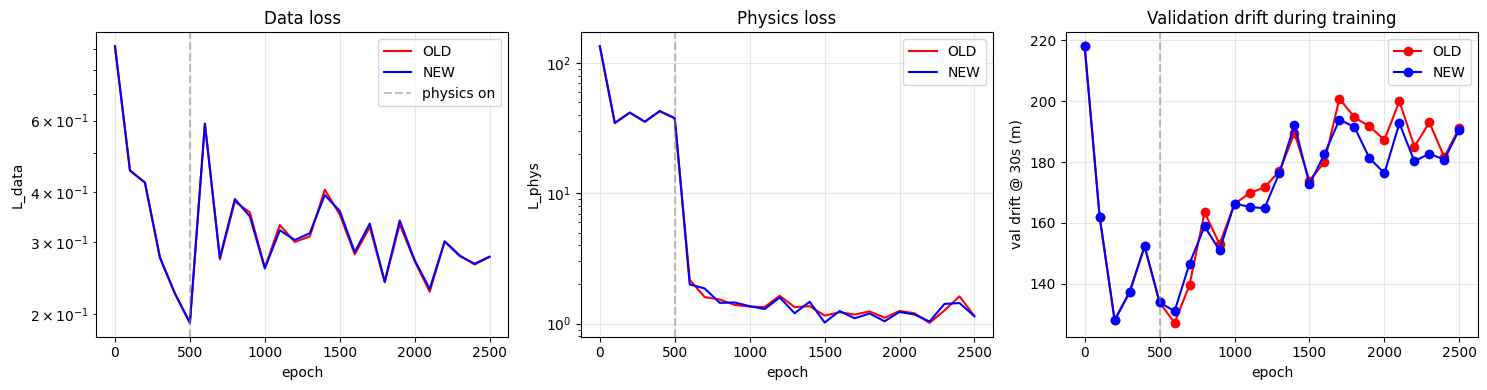

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_old["epoch"], hist_old["L_data"], 'r-', label='OLD')
axes[0].plot(hist_new["epoch"], hist_new["L_data"], 'b-', label='NEW')
axes[0].axvline(500, color='gray', ls='--', alpha=0.5, label='physics on')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('L_data')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Data loss')

axes[1].plot(hist_old["epoch"], hist_old["L_phys"], 'r-', label='OLD')
axes[1].plot(hist_new["epoch"], hist_new["L_phys"], 'b-', label='NEW')
axes[1].axvline(500, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('L_phys')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Physics loss')

axes[2].plot(hist_old["epoch"], hist_old["val_drift_30s_mean"], 'r-o', label='OLD')
axes[2].plot(hist_new["epoch"], hist_new["val_drift_30s_mean"], 'b-o', label='NEW')
axes[2].axvline(500, color='gray', ls='--', alpha=0.5)
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('val drift @ 30s (m)')
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title('Validation drift during training')

plt.tight_layout(); plt.show()

### sanity check 7a: did the bias head learn anything?

In [ ]:
print("Bias estimation quality on val windows (new model only):")
print(f"{'true b_a':>10} {'pred b_a':>10} {'true b_w':>10} {'pred b_w':>10}")
print("-" * 45)
true_bas, pred_bas, true_bws, pred_bws = [], [], [], []
model_new.eval()
with torch.no_grad():
    for w in val_windows[:20]:
        for s in range(2):
            noisy = inject_imu_noise(w, seed=900_000 + s + hash(w["drive"]) % 1000)
            # Build input
            N = len(w["ax"])
            t = torch.tensor(w["t"] / NORM["t_scale"], dtype=torch.float32,
                             device=DEVICE).unsqueeze(1)
            Sax_n = torch.tensor((noisy["ax"] - NORM["Sax_mean"]) / NORM["Sax_std"],
                                 dtype=torch.float32, device=DEVICE).unsqueeze(1)
            Say_n = torch.tensor((noisy["ay"] - NORM["Say_mean"]) / NORM["Say_std"],
                                 dtype=torch.float32, device=DEVICE).unsqueeze(1)
            Swz_n = torch.tensor((noisy["wz"] - NORM["Swz_mean"]) / NORM["Swz_std"],
                                 dtype=torch.float32, device=DEVICE).unsqueeze(1)
            v0_n = torch.full((N, 1), (w["v0"] - NORM["v0_mean"]) / NORM["v0_std"],
                              dtype=torch.float32, device=DEVICE)
            yaw0_n = torch.zeros((N, 1), dtype=torch.float32, device=DEVICE)
            v0_raw = torch.full((N, 1), w["v0"], dtype=torch.float32, device=DEVICE)
            yaw0_raw = torch.full((N, 1), w["yaw0"], dtype=torch.float32, device=DEVICE)
            inp = torch.cat([t, Sax_n, Say_n, Swz_n, v0_n, yaw0_n, yaw0_raw, v0_raw], dim=1)
            _, bias_pred = model_new(inp)
            true_bas.append(noisy["b0_ax"]); pred_bas.append(bias_pred[0].item())
            true_bws.append(noisy["b0_wz"]); pred_bws.append(bias_pred[1].item())

# Show first 10 in a table
for i in range(10):
    print(f"  {true_bas[i]:+10.3f} {pred_bas[i]:+10.3f} {true_bws[i]:+10.4f} {pred_bws[i]:+10.4f}")

# Correlation
true_bas = np.array(true_bas); pred_bas = np.array(pred_bas)
true_bws = np.array(true_bws); pred_bws = np.array(pred_bws)
corr_a = np.corrcoef(true_bas, pred_bas)[0, 1]
corr_w = np.corrcoef(true_bws, pred_bws)[0, 1]
print(f"\nCorrelation between true and predicted biases:")
print(f"  b_a:  r = {corr_a:.3f}")
print(f"  b_w:  r = {corr_w:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_bas, pred_bas, alpha=0.6)
lim_a = max(abs(true_bas).max(), abs(pred_bas).max()) * 1.1
axes[0].plot([-lim_a, lim_a], [-lim_a, lim_a], 'k--', alpha=0.5)
axes[0].set_xlabel('true b_a (m/s²)'); axes[0].set_ylabel('predicted b_a')
axes[0].set_title(f'Accel bias estimation (r={corr_a:.2f})'); axes[0].grid(alpha=0.3)
axes[1].scatter(true_bws, pred_bws, alpha=0.6)
lim_w = max(abs(true_bws).max(), abs(pred_bws).max()) * 1.1
axes[1].plot([-lim_w, lim_w], [-lim_w, lim_w], 'k--', alpha=0.5)
axes[1].set_xlabel('true b_w (rad/s)'); axes[1].set_ylabel('predicted b_w')
axes[1].set_title(f'Gyro bias estimation (r={corr_w:.2f})'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()